# Step 2: Importing Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('uber.csv')

print("Shape:", df.shape)
df.head()
df.tail()
df.dtypes

Shape: (200000, 9)


Unnamed: 0             int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [11]:
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


# Step 3: Dataset Exploration

In [9]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [5]:
# Shape & Columns
print(df.shape)
print(df.columns.tolist())

(200000, 9)
['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']


In [6]:
# Missing values
df.isnull().sum()


Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [7]:
# Duplicate records
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [8]:
# Target variable statistical summary (regression)
df['fare_amount'].describe()

count    200000.000000
mean         11.359955
std           9.901776
min         -52.000000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

# observations:
*fare_amount ranges from -$52 to $499 — negative fares are impossible, these are data errors.
*passenger_count ranges from 0 to 208 — a cab cannot carry 208 passengers, these are errors.
*pickup_latitude has a max value of 1644 — valid latitude is only between -90 and 90, confirming GPS recording errors.
*Only 1 missing value each in dropoff_longitude and dropoff_latitude — negligible, can be dropped directly.

# Feature understanding:
The dataset consists of several features used for predicting the target variable, **fare_amount**, which is a continuous variable representing the taxi fare. The features **pickup_longitude**, **pickup_latitude**, **dropoff_longitude**, and **dropoff_latitude** are continuous variables that capture the geographical locations of trip origins and destinations. The **passenger_count** feature is a discrete variable indicating the number of passengers in a trip. The **key** and **pickup_datetime** columns were removed from the analysis and were not used for model development.


# Step 4: Exploratory Data Analysis (EDA)

# Non-Visual Analysis

In [10]:
# Central tendency
df[['fare_amount','passenger_count']].agg(['mean','median','std'])

# Percentiles
df['fare_amount'].quantile([0.01, 0.25, 0.5, 0.75, 0.99])

# Correlation (only numeric, raw — distance not yet engineered)
df.corr(numeric_only=True)['fare_amount'].sort_values(ascending=False)

fare_amount          1.000000
pickup_longitude     0.010457
passenger_count      0.010150
dropoff_longitude    0.008986
Unnamed: 0           0.000589
pickup_latitude     -0.008481
dropoff_latitude    -0.011014
Name: fare_amount, dtype: float64

# Observations:
Raw lat/lon columns will show weak/near-zero correlation with fare_amount individually — this is expected, since raw coordinates alone mean nothing. Correlation will only become meaningful after distance is engineered in Step 6.

# Visual Analysis

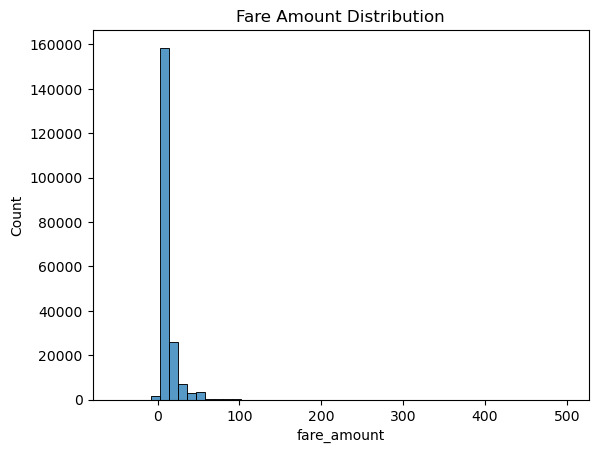

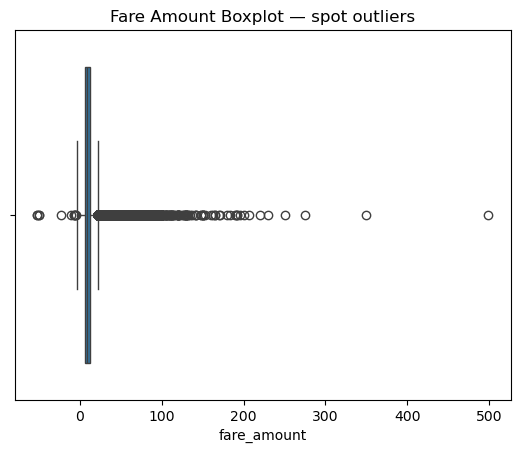

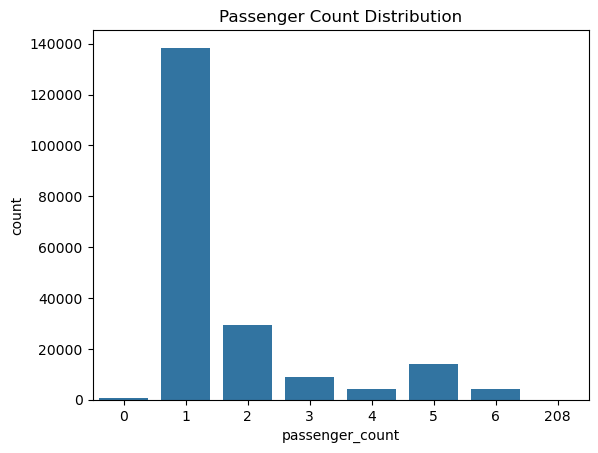

In [13]:
# Univariate
sns.histplot(df['fare_amount'], bins=50)
plt.title('Fare Amount Distribution')
plt.show()

sns.boxplot(x=df['fare_amount'])
plt.title('Fare Amount Boxplot — spot outliers')
plt.show()

sns.countplot(x=df['passenger_count'])
plt.title('Passenger Count Distribution')
plt.show()



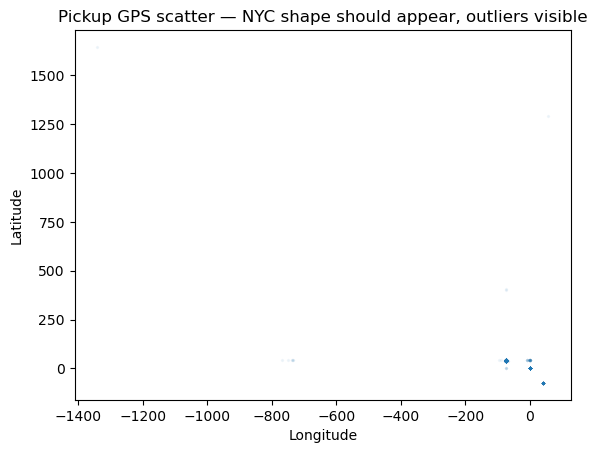

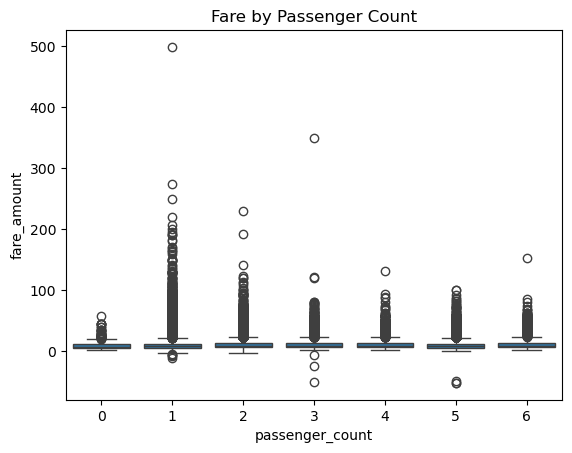

In [14]:
# Bivariate
plt.scatter(df['pickup_longitude'], df['pickup_latitude'], alpha=0.05, s=2)
plt.title('Pickup GPS scatter — NYC shape should appear, outliers visible')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.show()

sns.boxplot(x='passenger_count', y='fare_amount', data=df[df['passenger_count']<=6])
plt.title('Fare by Passenger Count')
plt.show()

In [15]:
df.rename(columns={'Unnamed: 0': 'trip_id'}, inplace=True)

In [16]:
df.columns

Index(['trip_id', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

# Preprocessing — Missing Values, Duplicates, Outliers

In [17]:
# Missing value treatment — drop (only 1 row affected, negligible)
df = df.dropna()

# Duplicate handling
df = df.drop_duplicates()

# Outlier treatment — domain-based filtering (more reliable than blind IQR for GPS data)
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] <= 200)]
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
df = df[(df['pickup_latitude'].between(40, 42)) &
        (df['pickup_longitude'].between(-75, -72)) &
        (df['dropoff_latitude'].between(40, 42)) &
        (df['dropoff_longitude'].between(-75, -72))]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (195096, 9)


# Step 5: Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

# Drop columns not used in this project (no datetime, no ID columns)
df = df.drop(columns=['trip_id', 'key', 'pickup_datetime'])

X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(156076, 5) (39020, 5)


# Step 6: Data Preprocessing

# Feature Engineering — GPS-only (no date-time features)

In [21]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

for d in [X_train, X_test]:
    d['distance_km'] = haversine(d['pickup_latitude'], d['pickup_longitude'],
                                  d['dropoff_latitude'], d['dropoff_longitude'])
    d['diff_lat'] = abs(d['dropoff_latitude'] - d['pickup_latitude'])
    d['diff_lon'] = abs(d['dropoff_longitude'] - d['pickup_longitude'])

    # Airport proximity features (Uber applies flat-rate airport pricing)
    JFK, LGA, EWR = (40.6413,-73.7781), (40.7769,-73.8740), (40.6895,-74.1745)
    d['dist_jfk'] = haversine(d['pickup_latitude'], d['pickup_longitude'], *JFK)
    d['dist_lga'] = haversine(d['pickup_latitude'], d['pickup_longitude'], *LGA)
    d['dist_ewr'] = haversine(d['pickup_latitude'], d['pickup_longitude'], *EWR)

    # Manhattan center distance
    d['dist_center'] = haversine(d['pickup_latitude'], d['pickup_longitude'], 40.7580, -73.9855)

# Remove near-zero-distance trips (pickup ≈ dropoff, likely cancelled/GPS noise)
mask = X_train['distance_km'] > 0.1
X_train, y_train = X_train[mask], y_train[mask]

# Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Note:
Encoding (Label/One-Hot) is not needed here — every feature is already numeric (GPS coordinates, distances, passenger count). No categorical columns exist in this version of the project.

# Step 7: Feature Selection

In [23]:
# Correlation analysis (after feature engineering)
corr = X_train.assign(fare_amount=y_train).corr()['fare_amount'].sort_values(ascending=False)
print(corr)

# Mutual information regression
from sklearn.feature_selection import mutual_info_regression
mi = mutual_info_regression(X_train, y_train)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
print(mi_series)

fare_amount          1.000000
distance_km          0.860170
diff_lon             0.809985
diff_lat             0.675908
dist_center          0.437688
pickup_longitude     0.424143
dist_ewr             0.356990
dropoff_longitude    0.302442
dist_lga             0.027721
passenger_count      0.012089
dropoff_latitude    -0.166170
pickup_latitude     -0.209889
dist_jfk            -0.440735
Name: fare_amount, dtype: float64
distance_km          0.915755
diff_lat             0.554057
diff_lon             0.533194
dropoff_longitude    0.128438
dropoff_latitude     0.116454
dist_center          0.106603
dist_ewr             0.106340
dist_lga             0.106313
pickup_longitude     0.100203
dist_jfk             0.092641
pickup_latitude      0.087022
passenger_count      0.006818
dtype: float64


# Observation:
Observation to justify in report: distance_km will rank #1 in both correlation and mutual information — this confirms distance is the primary driver of fare, validating the Haversine feature as the most important engineered feature in this project.

# Step 8: Hyperparameter Tuning

In [26]:
!pip install xgboost

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)
search = RandomizedSearchCV(xgb, param_grid, n_iter=15, cv=3,
                             scoring='neg_root_mean_squared_error',
                             random_state=42, n_jobs=-1)
search.fit(X_train, y_train)



,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.7, 0.8, ...]}"
,n_iter,15
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [31]:
print("Best params:", search.best_params_)
best_model = search.best_estimator_

Best params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}


In [43]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

# Step 9: Model Building

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=7),
    'XGBoost': XGBRegressor(**search.best_params_, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = model
print(results)

{'Linear Regression': LinearRegression(), 'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42), 'Random Forest': RandomForestRegressor(n_jobs=-1, random_state=42), 'KNN Regressor': KNeighborsRegressor(n_neighbors=7), 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)}


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, model in results.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")


Linear Regression
MAE  : 2.350
RMSE : 5.173
R²   : 0.706

Decision Tree
MAE  : 2.200
RMSE : 4.683
R²   : 0.759

Random Forest
MAE  : 2.178
RMSE : 4.224
R²   : 0.804

KNN Regressor
MAE  : 2.385
RMSE : 4.544
R²   : 0.774

XGBoost
MAE  : 2.200
RMSE : 4.558
R²   : 0.772


In [54]:
comparison = []

for name, model in results.items():
    y_pred = model.predict(X_test)

    comparison.append({
        'Model': name,
        'R2 Score': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })

import pandas as pd
comparison = pd.DataFrame(comparison)
comparison.sort_values('R2 Score', ascending=False)

,Model,R2 Score,RMSE
2,Random Forest,0.804274,4.224110
3,KNN Regressor,0.773527,4.543801
4,XGBoost,0.772158,4.557520
1,Decision Tree,0.759448,4.682907
0,Linear Regression,0.706456,5.173063


# Step 10: Model Evaluation

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

scores = []
for name, model in results.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    n, p = X_test.shape
    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
    scores.append([name, mae, rmse, r2, adj_r2])

results_df = pd.DataFrame(scores, columns=['Model','MAE','RMSE','R2','Adjusted_R2'])
results_df.sort_values('RMSE')

,Model,MAE,RMSE,R2,Adjusted_R2
2,Random Forest,2.177534,4.224110,0.804274,0.804214
3,KNN Regressor,2.385373,4.543801,0.773527,0.773457
4,XGBoost,2.200056,4.557520,0.772158,0.772087
1,Decision Tree,2.200343,4.682907,0.759448,0.759374
0,Linear Regression,2.349924,5.173063,0.706456,0.706366


# Step 11: Model Interpretation

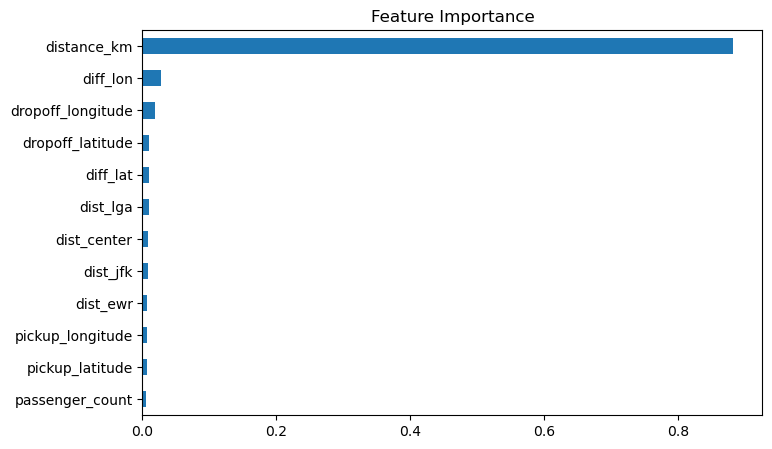

In [56]:
import matplotlib.pyplot as plt

best_model = results['XGBoost']  # update based on actual best from Step 10
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Feature Importance')
plt.show()

# Business insight to write:
distance_km will dominate feature importance, confirming fare is driven primarily by trip length. Airport-distance features (dist_jfk, dist_lga, dist_ewr) will show secondary importance, reflecting Uber's flat-rate airport pricing pattern. This translates to a business recommendation: pricing models should weight distance heavily, with fixed adjustments for airport zones.

# Step 12: Save the Model

In [58]:
import joblib

joblib.dump(best_model, 'cab_fare_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']